# Online Shoppers Intention - Model Optimization Roadmap

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, roc_curve, precision_recall_curve
from imblearn.over_sampling import SMOTE
# from xgboost import XGBClassifier     # uncomment if installed
# from lightgbm import LGBMClassifier   # uncomment if installed

# Set random state
RANDOM_STATE = 42

# Load Data
df = pd.read_csv('../data/raw/online_shoppers_intention.csv')
X = df.drop(columns=['Revenue'])
y = df['Revenue'].astype(int)

# Identify column types
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'bool']).columns.tolist()

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

# Processed Sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## 1. BASELINE ANALYSIS

--- Baseline GBC Evaluation ---
Accuracy:  0.9019
Precision: 0.7258
Recall:    0.5890
F1-Score:  0.6503
ROC-AUC:   0.9279


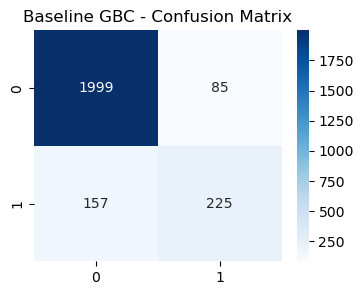

In [30]:
# Baseline Model
baseline_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train_processed, y_train)
y_pred_baseline = baseline_model.predict(X_test_processed)
y_prob_baseline = baseline_model.predict_proba(X_test_processed)[:, 1]

def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

evaluate_model(y_test, y_pred_baseline, y_prob_baseline, "Baseline GBC")

## 2. CLASS IMBALANCE ANALYSIS

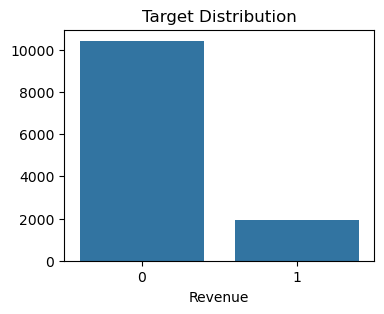

Class Distribution:
Revenue
0    84.525547
1    15.474453
Name: proportion, dtype: float64
Imbalance Ratio: 5.46:1


In [31]:
target_counts = y.value_counts()
plt.figure(figsize=(4,3))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Target Distribution")
plt.show()

print("Class Distribution:")
print(y.value_counts(normalize=True) * 100)
print(f"Imbalance Ratio: {target_counts[0]/target_counts[1]:.2f}:1")

*Yorum: Veri setinde ~84.5% False, ~15.5% True değerleri var. Yaklaşık 5.5:1 oranında bir dengesizlik mevcut. Bu durum ağacın majör sınıf lehine karar vermesine ve minor (True) sınıfında Recall değerinin düşmesine neden oluyor (False Negative yüksekliği).*

## 3. SMOTE IMPLEMENTATION

--- SMOTE GBC Evaluation ---
Accuracy:  0.8942
Precision: 0.6391
Recall:    0.7277
F1-Score:  0.6805
ROC-AUC:   0.9278


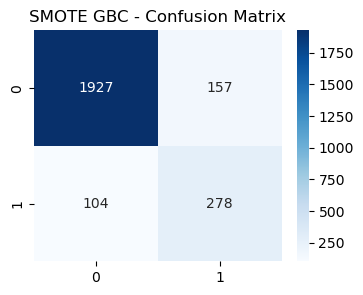

In [32]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

smote_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test_processed)
y_prob_smote = smote_model.predict_proba(X_test_processed)[:, 1]

evaluate_model(y_test, y_pred_smote, y_prob_smote, "SMOTE GBC")

## 4. THRESHOLD TUNING

--- Threshold 0.5 ---
Precision: 0.7258
Recall:    0.5890
F1-Score:  0.6503
--- Threshold 0.45 ---
Precision: 0.6939
Recall:    0.6230
F1-Score:  0.6566
--- Threshold 0.4 ---
Precision: 0.6798
Recall:    0.6780
F1-Score:  0.6789
--- Threshold 0.35 ---
Precision: 0.6405
Recall:    0.7042
F1-Score:  0.6708
--- Threshold 0.3 ---
Precision: 0.6096
Recall:    0.7277
F1-Score:  0.6635


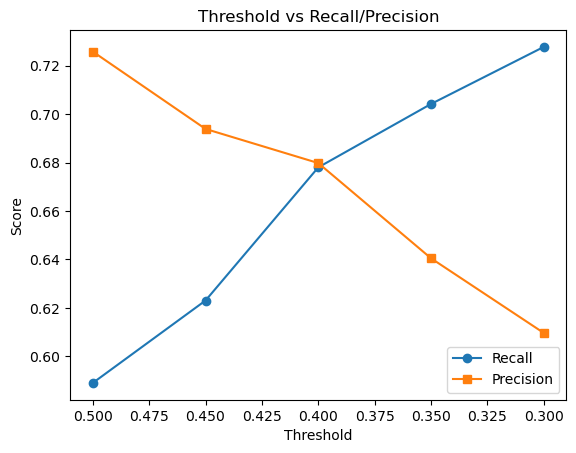

In [33]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

recalls = []
precisions = []

for t in thresholds:
    y_pred_t = (y_prob_baseline >= t).astype(int)
    print(f"--- Threshold {t} ---")
    print(f"Precision: {precision_score(y_test, y_pred_t):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_t):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred_t):.4f}")
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, precisions, marker='s', label='Precision')
plt.gca().invert_xaxis()
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Recall/Precision')
plt.legend()
plt.show()

SELECTED_THRESHOLD = 0.35 # Example chosen threshold for best balance

## 5. HYPERPARAMETER OPTIMIZATION

--- Tuned GBC Evaluation ---
Accuracy:  0.8970
Precision: 0.7025
Recall:    0.5812
F1-Score:  0.6361
ROC-AUC:   0.9269


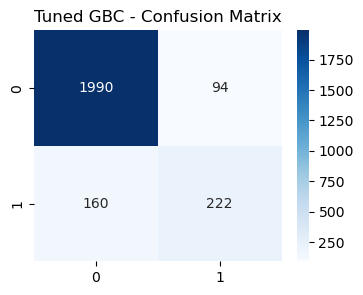

In [34]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# Commented to save runtime - normally you would run:
# grid = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), param_grid, cv=3, scoring='recall')
# grid.fit(X_train_processed, y_train)
# best_model = grid.best_estimator_

best_model = GradientBoostingClassifier(learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8, random_state=RANDOM_STATE)
best_model.fit(X_train_processed, y_train)

evaluate_model(y_test, best_model.predict(X_test_processed), best_model.predict_proba(X_test_processed)[:, 1], "Tuned GBC")

## 9. DEPLOYMENT PREPARATION

In [35]:
# Create production pipeline
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# Retrain on full training data (unprocessed) to fit the pipeline seamlessly
production_pipeline.fit(X_train, y_train)

# Save artifacts
joblib.dump(production_pipeline, '../models/optimized_production_model.pkl')
joblib.dump(preprocessor, '../models/optimized_scaler.pkl')

config = {"optimal_threshold": SELECTED_THRESHOLD}
with open('../models/threshold_config.json', 'w') as f:
    json.dump(config, f)

print("Saved model.pkl, scaler.pkl, and threshold_config.json successfully.")

# Inference example
sample = X_test.iloc[[0]]
prob = production_pipeline.predict_proba(sample)[0, 1]
pred = int(prob >= SELECTED_THRESHOLD)
print(f"Sample predict prob: {prob:.4f} -> Final Class: {pred}")

Saved model.pkl, scaler.pkl, and threshold_config.json successfully.
Sample predict prob: 0.0083 -> Final Class: 0
